# run_all — Multi-Model RSA Fitting

| 모델 | Role | 데이터 | RSA |
|------|------|--------|-----|
| A | Speaker / Listener | logit  | pRRSAc |
| B | Speaker / Listener | logit  | pRRSAf |
| C | Speaker / Listener | choice | pRRSAc |
| D | Speaker / Listener | choice | pRRSAf |

결과는 `results/traces/{llm_model}/{role}_{model_id}.nc` 에 저장됩니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

from rsa_models import (
    UTTERANCES, STATES, RELATIONS, N_utt, N_sta, N_rel,
    L0, state_vals, U_epi, U_soc_base,
    build_rsa_c, build_rsa_f,
    flat_speaker_logit, load_speaker_counts, load_speaker_logit_avg,
    flat_listener_logit, load_listener_counts, load_listener_logit_avg,
    save_trace, load_trace,
)

print('imports OK')

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


imports OK


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
LLM_MODELS  = ["qwen3_zero", "llama3_zero"]   # 돌릴 LLM 목록
MCMC_DRAWS  = 2000
MCMC_TUNE   = 1000
MCMC_CHAINS = 4
SKIP_IF_EXISTS = True   # 이미 저장된 trace가 있으면 건너뜀
# ─────────────────────────────────────────────────────────────────────────────

---
## Speaker Models (A – D)

In [3]:
def fit_speaker(llm_model):
    flat_sp        = flat_speaker_logit(llm_model)
    counts_speaker = load_speaker_counts(llm_model)

    # ── Model A: Logit × pRRSAc ───────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'speaker', 'A') is not None:
        print('  [skip] speaker A — already exists')
    elif flat_sp is None:
        print('  [skip] speaker A — no logit data')
    else:
        rel_idx, sta_idx, utt_idx, obs = flat_sp
        with pm.Model() as m:
            phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
            alpha = pm.Uniform('alpha', lower=0, upper=5)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            c     = pm.Normal('c',      mu=0,    sigma=3)
            sigma = pm.HalfNormal('sigma', sigma=1)
            log_S1, _ = build_rsa_c(phi, alpha, lam)
            pm.Normal('obs', mu=log_S1[rel_idx, utt_idx, sta_idx] + c,
                      sigma=sigma, observed=obs)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'speaker', 'A')

    # ── Model B: Logit × pRRSAf ───────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'speaker', 'B') is not None:
        print('  [skip] speaker B — already exists')
    elif flat_sp is None:
        print('  [skip] speaker B — no logit data')
    else:
        rel_idx, sta_idx, utt_idx, obs = flat_sp
        with pm.Model() as m:
            alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
            phi   = pm.Uniform('phi',   lower=0, upper=1)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            c     = pm.Normal('c',      mu=0,    sigma=3)
            sigma = pm.HalfNormal('sigma', sigma=1)
            log_S1, _ = build_rsa_f(alpha, phi, lam)
            pm.Normal('obs', mu=log_S1[rel_idx, utt_idx, sta_idx] + c,
                      sigma=sigma, observed=obs)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'speaker', 'B')

    # ── Model C: Choice × pRRSAc ──────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'speaker', 'C') is not None:
        print('  [skip] speaker C — already exists')
    elif counts_speaker is None:
        print('  [skip] speaker C — no choice data')
    else:
        n_sp = counts_speaker.sum(axis=-1)
        with pm.Model() as m:
            phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
            alpha = pm.Uniform('alpha', lower=0, upper=5)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            log_S1, _ = build_rsa_c(phi, alpha, lam)
            P_S1 = pt.exp(log_S1).transpose(0, 2, 1)   # (N_rel, N_sta, N_utt)
            pm.Multinomial('obs', n=n_sp, p=P_S1, observed=counts_speaker)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'speaker', 'C')

    # ── Model D: Choice × pRRSAf ──────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'speaker', 'D') is not None:
        print('  [skip] speaker D — already exists')
    elif counts_speaker is None:
        print('  [skip] speaker D — no choice data')
    else:
        n_sp = counts_speaker.sum(axis=-1)
        with pm.Model() as m:
            alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
            phi   = pm.Uniform('phi',   lower=0, upper=1)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            log_S1, _ = build_rsa_f(alpha, phi, lam)
            P_S1 = pt.exp(log_S1).transpose(0, 2, 1)
            pm.Multinomial('obs', n=n_sp, p=P_S1, observed=counts_speaker)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'speaker', 'D')


for llm in LLM_MODELS:
    print(f'\n=== Speaker: {llm} ===')
    fit_speaker(llm)


=== Speaker: qwen3_zero ===
flat_speaker_logit_qwen3_zero: 500 obs (5 per condition)
파싱 실패: 0/1000 (0.0%)
speaker_counts_qwen3_zero: (4, 5, 5), total=1000
[없음] results/traces/qwen3_zero/speaker_A.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, alpha, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.


saved → results/traces/qwen3_zero/speaker_A.nc
[없음] results/traces/qwen3_zero/speaker_B.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam, c, sigma]


...

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


saved → results/traces/llama3_zero/speaker_C.nc
[없음] results/traces/llama3_zero/speaker_D.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


saved → results/traces/llama3_zero/speaker_D.nc


---
## Listener Models (A – D)

In [4]:
def fit_listener(llm_model):
    flat_li         = flat_listener_logit(llm_model)
    counts_listener = load_listener_counts(llm_model)

    # ── Model A: Logit × pRRSAc ───────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'listener', 'A') is not None:
        print('  [skip] listener A — already exists')
    elif flat_li is None:
        print('  [skip] listener A — no logit data')
    else:
        rel_idx, utt_idx, sta_idx, obs = flat_li
        with pm.Model() as m:
            phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
            alpha = pm.Uniform('alpha', lower=0, upper=5)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            c     = pm.Normal('c',      mu=0,    sigma=3)
            sigma = pm.HalfNormal('sigma', sigma=1)
            _, log_L1 = build_rsa_c(phi, alpha, lam)
            pm.Normal('obs', mu=log_L1[rel_idx, utt_idx, sta_idx] + c,
                      sigma=sigma, observed=obs)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'listener', 'A')

    # ── Model B: Logit × pRRSAf ───────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'listener', 'B') is not None:
        print('  [skip] listener B — already exists')
    elif flat_li is None:
        print('  [skip] listener B — no logit data')
    else:
        rel_idx, utt_idx, sta_idx, obs = flat_li
        with pm.Model() as m:
            alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
            phi   = pm.Uniform('phi',   lower=0, upper=1)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            c     = pm.Normal('c',      mu=0,    sigma=3)
            sigma = pm.HalfNormal('sigma', sigma=1)
            _, log_L1 = build_rsa_f(alpha, phi, lam)
            pm.Normal('obs', mu=log_L1[rel_idx, utt_idx, sta_idx] + c,
                      sigma=sigma, observed=obs)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'listener', 'B')

    # ── Model C: Choice × pRRSAc ──────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'listener', 'C') is not None:
        print('  [skip] listener C — already exists')
    elif counts_listener is None:
        print('  [skip] listener C — no choice data')
    else:
        n_li = counts_listener.sum(axis=-1)
        with pm.Model() as m:
            phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
            alpha = pm.Uniform('alpha', lower=0, upper=5)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            _, log_L1 = build_rsa_c(phi, alpha, lam)
            pm.Multinomial('obs', n=n_li, p=pt.exp(log_L1), observed=counts_listener)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'listener', 'C')

    # ── Model D: Choice × pRRSAf ──────────────────────────────────────────────
    if SKIP_IF_EXISTS and load_trace(llm_model, 'listener', 'D') is not None:
        print('  [skip] listener D — already exists')
    elif counts_listener is None:
        print('  [skip] listener D — no choice data')
    else:
        n_li = counts_listener.sum(axis=-1)
        with pm.Model() as m:
            alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
            phi   = pm.Uniform('phi',   lower=0, upper=1)
            lam   = pm.Uniform('lam',   lower=0, upper=20)
            _, log_L1 = build_rsa_f(alpha, phi, lam)
            pm.Multinomial('obs', n=n_li, p=pt.exp(log_L1), observed=counts_listener)
        with m:
            tr = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                           target_accept=0.95, return_inferencedata=True)
        save_trace(tr, llm_model, 'listener', 'D')


for llm in LLM_MODELS:
    print(f'\n=== Listener: {llm} ===')
    fit_listener(llm)


=== Listener: qwen3_zero ===
flat_listener_logit_qwen3_zero: 500 obs (5 per condition)
파싱 실패: 0/1000 (0.0%)
listener_counts_qwen3_zero: (4, 5, 5), total=1000
[없음] results/traces/qwen3_zero/listener_A.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, alpha, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


saved → results/traces/qwen3_zero/listener_A.nc
[없음] results/traces/qwen3_zero/listener_B.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam, c, sigma]


...

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


saved → results/traces/llama3_zero/listener_C.nc
[없음] results/traces/llama3_zero/listener_D.nc


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


saved → results/traces/llama3_zero/listener_D.nc


---
## Results — Convergence & Parameter Summary

In [5]:
# ── 수렴 진단 ─────────────────────────────────────────────────────────────────
# role_model_id → 주 파라미터 이름
PRIMARY_PARAM = {
    ('speaker',  'A'): 'phi',
    ('speaker',  'B'): 'alpha',
    ('speaker',  'C'): 'phi',
    ('speaker',  'D'): 'alpha',
    ('listener', 'A'): 'phi',
    ('listener', 'B'): 'alpha',
    ('listener', 'C'): 'phi',
    ('listener', 'D'): 'alpha',
}

rows = []
for llm in LLM_MODELS:
    for role in ['speaker', 'listener']:
        for mid in ['A', 'B', 'C', 'D']:
            tr = load_trace(llm, role, mid)
            if tr is None:
                rows.append({'LLM': llm, 'Role': role, 'Model': mid,
                             'max_rhat': float('nan'), 'status': '?'})
                continue
            pname = PRIMARY_PARAM[(role, mid)]
            rhat_vals = [float(az.rhat(tr)[v].values.max())
                         for v in [pname, 'lam'] if v in tr.posterior]
            max_r = max(rhat_vals)
            status = '✓' if max_r < 1.01 else '△' if max_r < 1.05 else '✗'
            rows.append({'LLM': llm, 'Role': role, 'Model': mid,
                         'max_rhat': round(max_r, 4), 'status': status})

df_conv = pd.DataFrame(rows)
print(df_conv.to_string(index=False))

        LLM     Role Model  max_rhat status
 qwen3_zero  speaker     A    1.0040      ✓
 qwen3_zero  speaker     B    1.0018      ✓
 qwen3_zero  speaker     C    1.0058      ✓
 qwen3_zero  speaker     D    1.0008      ✓
 qwen3_zero listener     A    1.0016      ✓
 qwen3_zero listener     B    1.0012      ✓
 qwen3_zero listener     C    1.0036      ✓
 qwen3_zero listener     D    1.0035      ✓
llama3_zero  speaker     A    1.0038      ✓
llama3_zero  speaker     B    1.0029      ✓
llama3_zero  speaker     C    1.0060      ✓
llama3_zero  speaker     D    1.0092      ✓
llama3_zero listener     A    1.0034      ✓
llama3_zero listener     B    1.0009      ✓
llama3_zero listener     C    1.4395      ✗
llama3_zero listener     D    1.0022      ✓


In [6]:
# ── 파라미터 요약 테이블 — pRRSAc φ (per relationship) ──────────────────────
# Human reference
HUMAN_PHI_SP = {'Enge Freundin': 0.45, 'Entfernte Kollegin': 0.31,
                'Lockere Chefin': 0.37, 'Gefürchtete Chefin': 0.22}
HUMAN_PHI_LI = {'Enge Freundin': 0.45, 'Entfernte Kollegin': 0.31,
                'Lockere Chefin': 0.371, 'Gefürchtete Chefin': 0.22}

rows = []
for rel in RELATIONS:
    row = {'Relationship': rel,
           'Human (SP)': HUMAN_PHI_SP[rel],
           'Human (LI)': HUMAN_PHI_LI[rel]}
    for llm in LLM_MODELS:
        for role, model_id, human_ref in [
            ('speaker',  'A', None),
            ('listener', 'A', None),
        ]:
            tr = load_trace(llm, role, model_id)
            if tr is None:
                row[f'{llm[:6]} {role[:2].upper()} φ'] = float('nan')
            else:
                r_i = RELATIONS.index(rel)
                samp = tr.posterior['phi'].values[:, :, r_i]
                row[f'{llm[:6]} {role[:2].upper()} φ'] = round(float(samp.mean()), 3)
    rows.append(row)

df_phi = pd.DataFrame(rows)
print('\npRRSAc — φ (mean posterior)')
print(df_phi.to_string(index=False))


pRRSAc — φ (mean posterior)
      Relationship  Human (SP)  Human (LI)  qwen3_ SP φ  qwen3_ LI φ  llama3 SP φ  llama3 LI φ
     Enge Freundin        0.45       0.450        0.631        0.203        0.523        0.844
Entfernte Kollegin        0.31       0.310        0.644        0.210        0.495        0.807
    Lockere Chefin        0.37       0.371        0.654        0.177        0.521        0.690
Gefürchtete Chefin        0.22       0.220        0.618        0.195        0.506        0.567


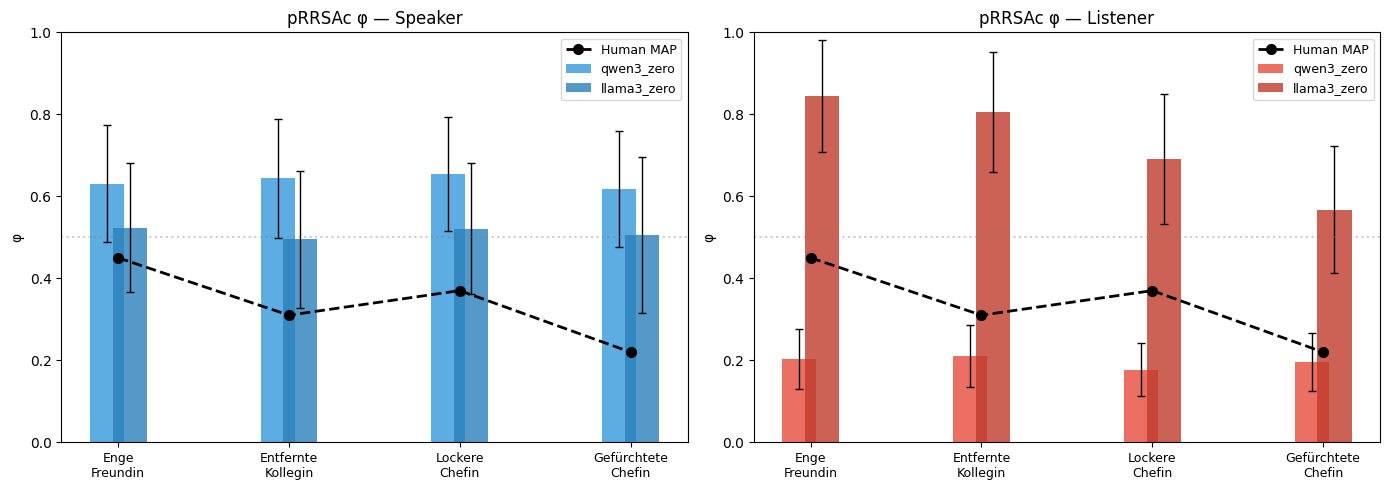

In [7]:
# ── φ 비교 플롯 (pRRSAc, Model A) — Speaker vs Listener × LLM ──────────────
HUMAN_PHI_SP = {'Enge Freundin': 0.45, 'Entfernte Kollegin': 0.31,
                'Lockere Chefin': 0.37, 'Gefürchtete Chefin': 0.22}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [r.replace(' ', '\n') for r in RELATIONS]
x = np.arange(N_rel)
width = 0.2

role_colors = {'speaker': ['#3498db', '#2980b9'],
               'listener': ['#e74c3c', '#c0392b']}

for ax_i, role in enumerate(['speaker', 'listener']):
    ax = axes[ax_i]
    n_bars = len(LLM_MODELS)
    offsets = np.linspace(-n_bars*width/2, n_bars*width/2, n_bars+2)[1:-1]

    for i, llm in enumerate(LLM_MODELS):
        tr = load_trace(llm, role, 'A')
        if tr is None: continue
        samp = tr.posterior['phi'].values   # (chain, draw, N_rel)
        m = samp.mean(axis=(0, 1))
        s = samp.std(axis=(0, 1))
        ax.bar(x + offsets[i], m, width, label=llm,
               color=role_colors[role][i], alpha=0.8)
        ax.errorbar(x + offsets[i], m, s, fmt='none',
                    color='black', capsize=3, lw=1)

    ax.plot(x, [HUMAN_PHI_SP[r] for r in RELATIONS],
            'k--o', lw=2, ms=7, label='Human MAP')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('φ'); ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f'pRRSAc φ — {role.capitalize()}')

plt.tight_layout()
plt.savefig('results/all_phi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

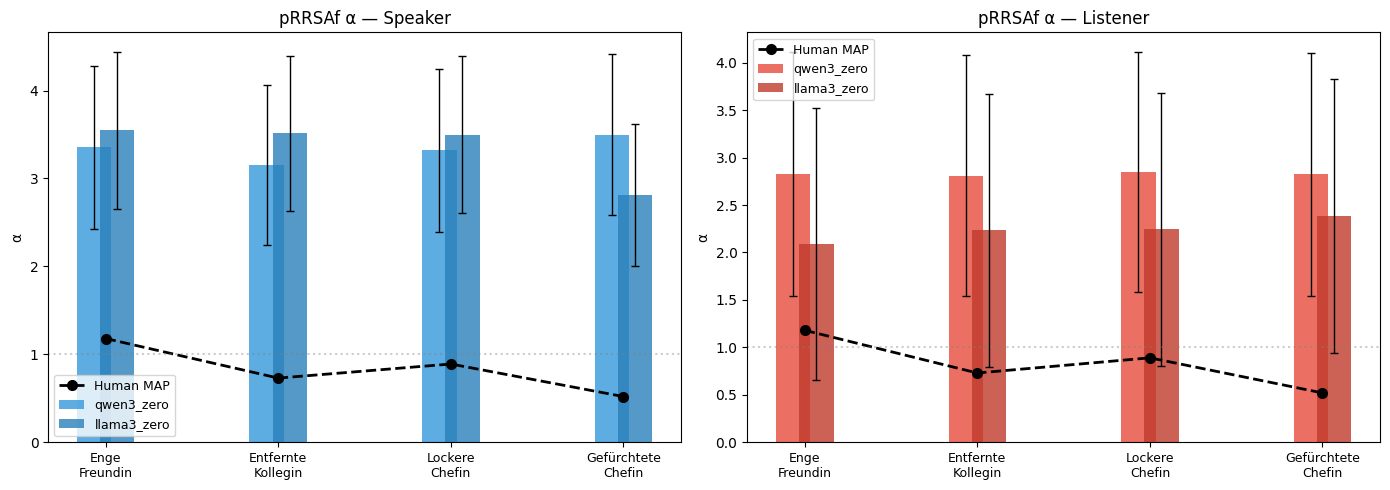

In [8]:
# ── α 비교 플롯 (pRRSAf, Model B) — Speaker vs Listener × LLM ───────────────
HUMAN_ALPHA_SP = {'Enge Freundin': 1.18, 'Entfernte Kollegin': 0.73,
                  'Lockere Chefin': 0.89, 'Gefürchtete Chefin': 0.52}
HUMAN_ALPHA_LI = {'Enge Freundin': 1.18, 'Entfernte Kollegin': 0.73,
                  'Lockere Chefin': 0.89, 'Gefürchtete Chefin': 0.52}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [r.replace(' ', '\n') for r in RELATIONS]
x = np.arange(N_rel)
width = 0.2

role_colors = {'speaker': ['#3498db', '#2980b9'],
               'listener': ['#e74c3c', '#c0392b']}

for ax_i, role in enumerate(['speaker', 'listener']):
    ax = axes[ax_i]
    human_ref = HUMAN_ALPHA_SP if role == 'speaker' else HUMAN_ALPHA_LI
    n_bars = len(LLM_MODELS)
    offsets = np.linspace(-n_bars*width/2, n_bars*width/2, n_bars+2)[1:-1]

    for i, llm in enumerate(LLM_MODELS):
        tr = load_trace(llm, role, 'B')
        if tr is None: continue
        samp = tr.posterior['alpha'].values   # (chain, draw, N_rel)
        m = samp.mean(axis=(0, 1))
        s = samp.std(axis=(0, 1))
        ax.bar(x + offsets[i], m, width, label=llm,
               color=role_colors[role][i], alpha=0.8)
        ax.errorbar(x + offsets[i], m, s, fmt='none',
                    color='black', capsize=3, lw=1)

    ax.plot(x, [human_ref[r] for r in RELATIONS],
            'k--o', lw=2, ms=7, label='Human MAP')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('α'); ax.set_ylim(0, None)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f'pRRSAf α — {role.capitalize()}')

plt.tight_layout()
plt.savefig('results/all_alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()